# 07 — SAM 3: Prompts de texto

## ¿Qué vamos a construir hoy?

Segmentarás objetos describiendo en texto lo que buscas — sin necesitar un detector
previo como YOLO. SAM 3 entiende el lenguaje natural y encuentra todas las instancias
del concepto que le pidas en la imagen.

## Texto como prompt

SAM las coordenadas de una caja: *"el objeto está aquí, segméntalo"*.
Con SAM 3, también puedes decirle: *"encuentra y segmenta todo lo que sea una persona"*.

```
Prompt bbox:  SAM(image, bboxes=[[100,50,300,400]])  ← tú ya sabes dónde está
Prompt texto: predictor(text=["person"])             ← SAM lo busca solo
```

Cuándo usar cada uno:
- **Texto** → no tienes detector previo, describes lo que buscas en lenguaje natural.
- **Bbox** → ya tienes un detector entrenado para tu dominio y quieres mayor precisión.

In [1]:
!pip install supervision ultralytics
import supervision as sv
from ultralytics.models.sam import SAM3SemanticPredictor
from ultralytics import YOLO, SAM
import torch
import cv2
import matplotlib.pyplot as plt
import urllib.request
from pathlib import Path

Path("assets").mkdir(exist_ok=True)
urllib.request.urlretrieve("https://ultralytics.com/images/bus.jpg",    "assets/bus.jpg")
urllib.request.urlretrieve("https://ultralytics.com/images/zidane.jpg", "assets/zidane.jpg")

image = cv2.imread("assets/bus.jpg")


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\bruni\miniconda3\Lib\site-packages\supervision\annotators\core.py:10: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  from scipy.interpolate import splev, splprep


## Los parámetros de `overrides`

El diccionario `overrides` configura cómo funciona el predictor:

| Parámetro | Valor | Significado |
|-----------|-------|-------------|
| `conf` | `0.25` | Umbral de confianza mínimo. Solo se incluyen detecciones con score ≥ 0.25. Sube este valor para reducir falsos positivos; bájalo para capturar más objetos. |
| `task` | `"segment"` | Le dice a Ultralytics que el objetivo es segmentación (no detección simple ni clasificación). |
| `mode` | `"predict"` | Modo inferencia. Otras opciones son `"train"` y `"val"`, pero para usar el modelo siempre es `"predict"`. |
| `model` | `"sam3.pt"` | Archivo de pesos del modelo. Si lo tienes en otra ruta, cambia este valor. |

El parámetro opcional `half=True` activa precisión FP16 (solo en GPU), lo que
reduce el consumo de memoria y acelera la inferencia sin pérdida significativa de precisión.


In [ ]:
sam_path = 'sam3.pt'
overrides = dict(conf=0.85, task='segment', mode='predict', model=sam_path)
if torch.cuda.is_available():
    overrides['half'] = True

predictor = SAM3SemanticPredictor(overrides=overrides)
print('Precitor listo')

sam_model = SAM('sam3.pt')

Precitor listo


In [ ]:
predictor.set_image(image)

results = predictor(text = ['person'])[0]
detections = sv.Detections.from_ultralytics(results)

print(f"Objectos encontrados: {len(detections)}")
print(f"Tiene mascara? {detections.mask is not None}")

Ultralytics 8.4.46  Python-3.11.15 torch-2.4.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Ti, 12282MiB)
WARNING imgsz=[640] must be multiple of max stride 14, updating to [644]

0: 644x644 4 persons, 46.0ms
Speed: 2.5ms preprocess, 46.0ms inference, 2.4ms postprocess per image at shape (1, 3, 644, 644)
Results saved to C:\Users\bruni\OneDrive\Desktop\complemento_semana_2\runs\segment\predict-3
Objectos encontrados: 4
Tiene mascara? True


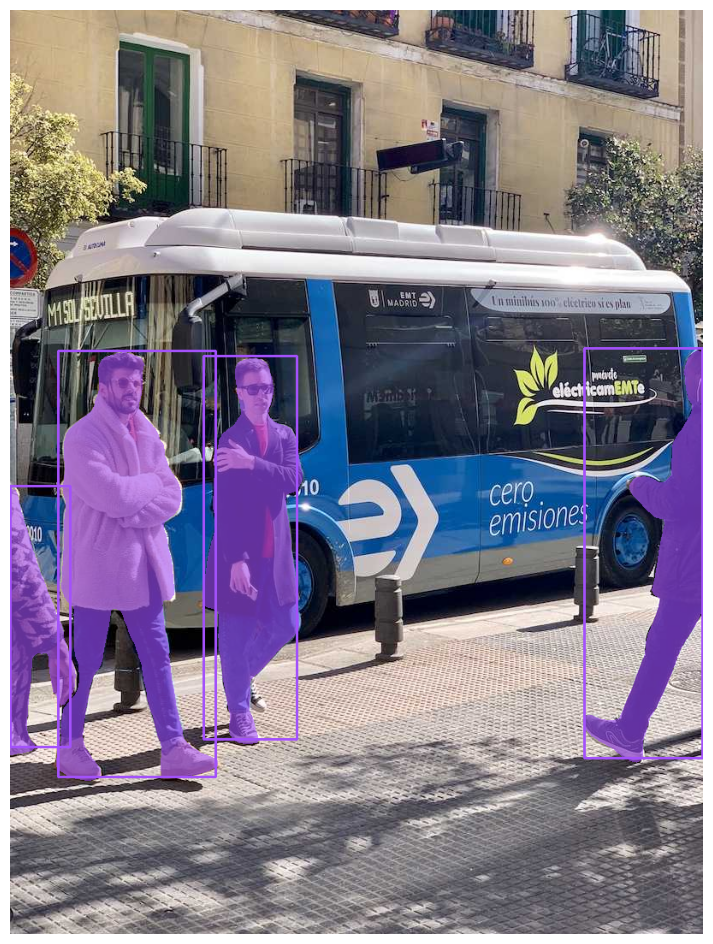

In [10]:
box_annotator = sv.BoxAnnotator()
mask_annotator = sv.MaskAnnotator(opacity = 0.6)

annotated = box_annotator.annotate(image.copy(), detections = detections)
annotated = mask_annotator.annotate(annotated, detections=detections)

sv.plot_image(annotated)

In [11]:
if detections.confidence is not None:
    for i, conf in enumerate(detections.confidence):
        area = int(detections.mask[i].sum()) if detections.mask is not None else 0
        print(f"Objeto {i}: confianza={conf:.3f} area={area:,} px2")

Objeto 0: confianza=0.972 area=31,805 px2
Objeto 1: confianza=0.970 area=45,027 px2
Objeto 2: confianza=0.966 area=20,826 px2
Objeto 3: confianza=0.943 area=11,311 px2



0: 644x644 1 vehicle, 178.9ms
Speed: 7.6ms preprocess, 178.9ms inference, 1.1ms postprocess per image at shape (1, 3, 644, 644)
Results saved to C:\Users\bruni\OneDrive\Desktop\complemento_semana_2\runs\segment\predict-3

0: 644x644 1 bus, 48.0ms
Speed: 2.2ms preprocess, 48.0ms inference, 0.9ms postprocess per image at shape (1, 3, 644, 644)
Results saved to C:\Users\bruni\OneDrive\Desktop\complemento_semana_2\runs\segment\predict-3

0: 644x644 4 persons, 45.6ms
Speed: 2.2ms preprocess, 45.6ms inference, 0.9ms postprocess per image at shape (1, 3, 644, 644)
Results saved to C:\Users\bruni\OneDrive\Desktop\complemento_semana_2\runs\segment\predict-3


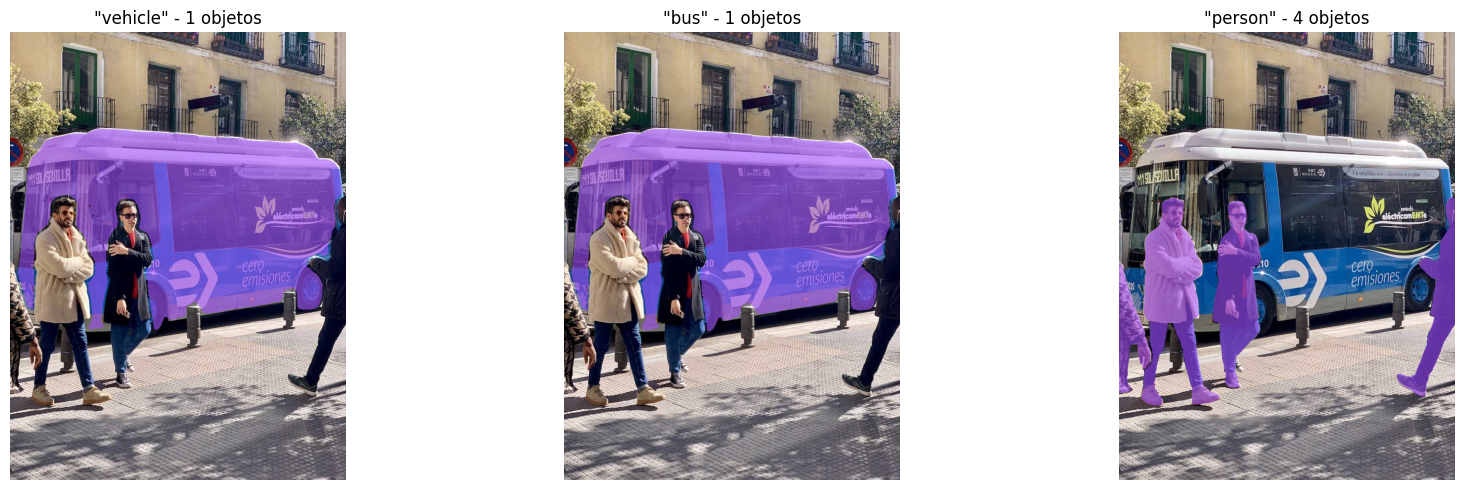

In [14]:
fig, axes = plt.subplots(1, 3, figsize = (18, 5))
for ax, concepto in zip(axes, ['vehicle', 'bus', 'person']):
    res = predictor(text=[concepto])[0]
    det = sv.Detections.from_ultralytics(res)
    scn = sv.MaskAnnotator(opacity = 0.6).annotate(scene=image.copy(), detections=det)
    ax.imshow(cv2.cvtColor(scn, cv2.COLOR_BGR2RGB))
    ax.set_title(f'"{concepto}" - {len(det)} objetos')
    ax.axis('off')
plt.tight_layout()
plt.show()